# Finite vs Asymptotic QKD Comparison Report

This notebook evaluates the performance penalties of finite-key analysis compared to theoretical asymptotic limits across BB84, COW, and DPS Quantum Key Distribution protocols.

In theoretical (asymptotic) scenarios, QKD protocols assume an infinite number of exchanged pulses, allowing for perfect parameter estimation. However, in practical implementations, key sizes are finite, leading to statistical fluctuations. This requires attributing a larger portion of the key to privacy amplification and parameter estimation to guarantee security bounds ($\epsilon_s$), which ultimately depletes the secret key rate (SKR).

This report aims to demonstrate the specific limiting factors and cutoff thresholds where finite protocol performance falls to zero due to these constraints.

## 1. Import Dependencies and Define Mostly Common Parameters

First, we set up our global environment and define the common baseline hardware constants.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
from matplotlib.ticker import ScalarFormatter

# Configure Matplotlib for scientific publication style
matplotlib.rcParams.update({
    "font.family": "serif",
    "mathtext.fontset": "cm",
    "axes.labelsize": 16,
    "axes.titlesize": 18,
    "legend.fontsize": 14,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "lines.linewidth": 2.5
})

# ==========================================
# Global Common Parameters for all protocols
# ==========================================
# Derived strictly from the parameters_comp_finite_asym.txt file limits

COMMON_PARAMS = {
    'mu': 0.1,                      # Common mean photon number
    'alpha': 0.2,                   # Fiber loss coefficient (dB/km)
    'eta_det': 0.1,                 # Detector efficiency 
    'dark_count_hz': 1000,          # Dark count rate (Hz)
    'time_window': 1e-9,            # Detector time window (1 ns)
    'repetition_rate': 1e6,         # System clock / Repetition rate (1 MHz)
    'f_ec': 1.16,                   # Error correction efficiency factor
    'epsilon_sec': 1e-10,           # Common security parameter (epsilon)
    
    # FSO specific parameters
    'transmitter_diameter': 0.1,    # Transmitter diameter (m)
    'receiver_diameter': 0.3,       # Receiver diameter (m)
    'beam_divergence': 0.001,       # Beam divergence (rad)
    'atmos_attenuation': 0.2        # Atmospheric attenuation (dB/km)
}
# Derived explicit probability (used by DPS protocols)
COMMON_PARAMS['dark_count_prob'] = COMMON_PARAMS['dark_count_hz'] * COMMON_PARAMS['time_window']

# Standard test spaces
distances = np.linspace(0, 200, 40)
mu_values = np.linspace(0.001, 0.6, 40) 

# Standard Finite Block Sizes (N_em) for comparison mapped to labels
BLOCK_SIZES = [1e8, 1e13] 
BLOCK_LABELS = ["10^8", "10^{13}"]

print("Global configuration initialized.")
print(f"-> Base Hardware: {COMMON_PARAMS['alpha']} dB/km (Fiber), {COMMON_PARAMS['atmos_attenuation']} dB/km (FSO)")
print(f"-> Detector: Efficiency {COMMON_PARAMS['eta_det']}, DCR {COMMON_PARAMS['dark_count_hz']} Hz (Prob {COMMON_PARAMS['dark_count_prob']})")

Global configuration initialized.
-> Base Hardware: 0.2 dB/km (Fiber), 0.2 dB/km (FSO)
-> Detector: Efficiency 0.1, DCR 1000 Hz (Prob 1.0000000000000002e-06)


## 2. BB84 Protocol Assessment

In BB84, under finite-key constraints, the estimation of the phase error rate from the bit error rate introduces statistical inaccuracies. Parameter estimation in the decoy-state BB84 protocol requires a rigid balance; transmitting too few decoy states ruins bounds estimates, while transmitting too many depletes the raw key.

Running BB84 Simulations (fiber)...


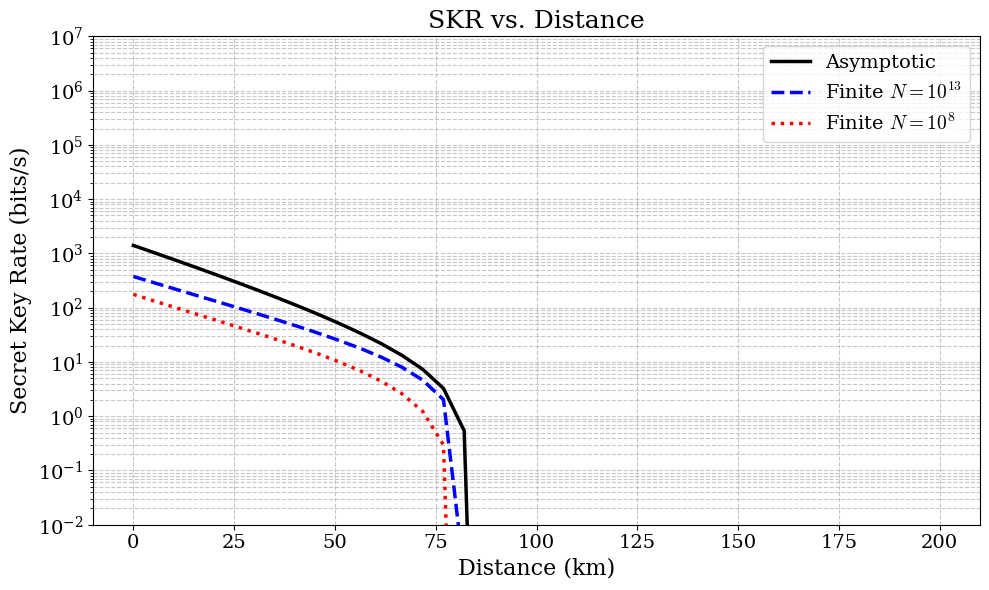

Running BB84 Simulations (fso)...


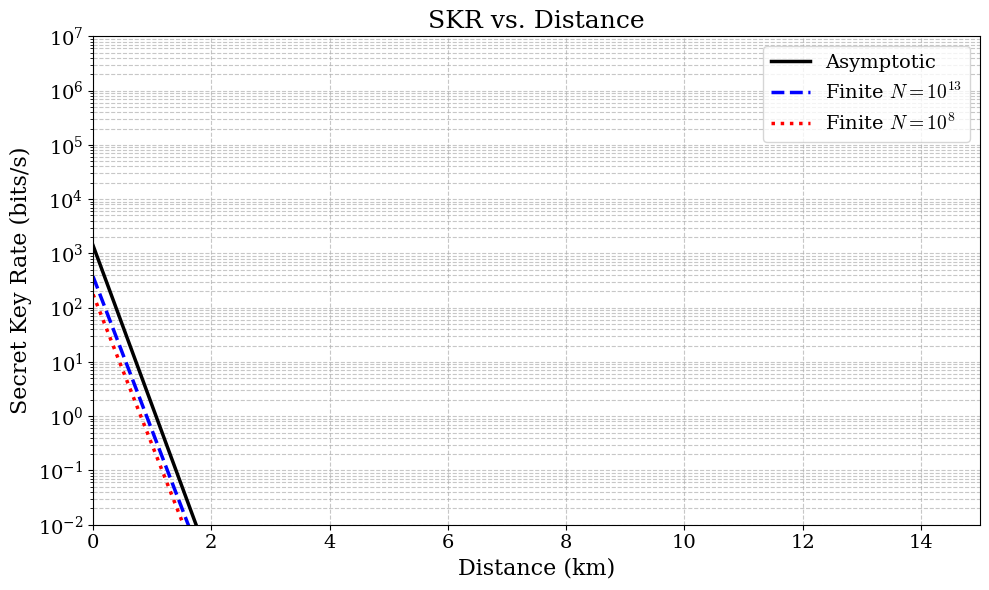

In [2]:
# Import BB84 simulators
from ThOPqkdsim.simBB84 import BB84Simulator as BB84_Asymptotic
from ThOPqkdsim.bb84_finite import Protocol as BB84_Finite
from ThOPqkdsim.bb84_finite import Source, Channel as FiniteChannel, Detector as FiniteDetector

modes = ['fiber', 'fso']

for mode in modes:
    # Data arrays for Distance variations (fixed mu)
    skr_asym_bb84_dist, qber_asym_bb84_dist = [], []
    skr_fin_bb84_dist_N1, qber_fin_bb84_dist_N1 = [], []
    skr_fin_bb84_dist_N2, qber_fin_bb84_dist_N2 = [], []
    
    # Data arrays for Mu variations (fixed distance)
    skr_asym_bb84_mu, qber_asym_bb84_mu = [], []
    skr_fin_bb84_mu_N1, qber_fin_bb84_mu_N1 = [], []
    skr_fin_bb84_mu_N2, qber_fin_bb84_mu_N2 = [], []
    
    # Setup instances
    asym_bb84 = BB84_Asymptotic(
        mu=COMMON_PARAMS['mu'],
        detector_efficiency=COMMON_PARAMS['eta_det'],
        channel_base_efficiency=1.0,
        dark_count_rate=COMMON_PARAMS['dark_count_hz'],
        time_window=COMMON_PARAMS['time_window'],
        attenuation=COMMON_PARAMS['alpha'],
        channel_mode=mode,
        atmos_attenuation=COMMON_PARAMS['atmos_attenuation'],
        transmitter_diameter=COMMON_PARAMS['transmitter_diameter'],
        receiver_diameter=COMMON_PARAMS['receiver_diameter'],
        beam_divergence=COMMON_PARAMS['beam_divergence'],
        misalignment_base=0.015,
        misalignment_factor=0.0004,
        ec_eff_factor=COMMON_PARAMS['f_ec']
    )

    fin_source = Source(freq=COMMON_PARAMS['repetition_rate'], mean_photon_num=COMMON_PARAMS['mu'], q=1.0, alignment_error=0.080)
    fin_detector = FiniteDetector(efficiency=COMMON_PARAMS['eta_det'], dark_count_rate=COMMON_PARAMS['dark_count_hz'], time_window=COMMON_PARAMS['time_window'])
    fin_channel = FiniteChannel(
        att_db_km=COMMON_PARAMS['alpha'], 
        channel_mode=mode,
        atmos_attenuation=COMMON_PARAMS['atmos_attenuation'],
        transmitter_diameter=COMMON_PARAMS['transmitter_diameter'],
        receiver_diameter=COMMON_PARAMS['receiver_diameter'],
        beam_divergence=COMMON_PARAMS['beam_divergence']
    )
    fin_protocol = BB84_Finite(fin_source, fin_channel, fin_detector, epsilon_sec=COMMON_PARAMS['epsilon_sec'], f_ec=COMMON_PARAMS['f_ec'])

    print(f"Running BB84 Simulations ({mode})...")
    
    # --- 1. Iterate over Distances ---
    for d in distances:
        # Asymptotic
        asym_bb84.update_distance(d)
        asym_bb84.update_mu(COMMON_PARAMS['mu'])
        asym_bb84.repetition_rate = COMMON_PARAMS['repetition_rate']
        
        raw_rate = asym_bb84.calculate_skr()
        skr_asym_bb84_dist.append(max(1e-12, raw_rate))
        qber_asym_bb84_dist.append(asym_bb84.calculate_quantum_bit_error_rate())
        
        # Finite
        fin_channel.L = d
        fin_source.mu = COMMON_PARAMS['mu']
        
        _, fin_qber, _ = fin_protocol.calculate_system_params()
        qber_fin_bb84_dist_N1.append(fin_qber * 100) # percentage
        qber_fin_bb84_dist_N2.append(fin_qber * 100)
        
        r1, _ = fin_protocol.calculate_skr(BLOCK_SIZES[0])
        skr_fin_bb84_dist_N1.append(max(1e-12, r1))
        
        r2, _ = fin_protocol.calculate_skr(BLOCK_SIZES[1])
        skr_fin_bb84_dist_N2.append(max(1e-12, r2))


    # --- Plotting ---
    plt.figure(figsize=(10, 6))

    plt.semilogy(distances, skr_asym_bb84_dist, 'k-', label='Asymptotic')
    plt.semilogy(distances, skr_fin_bb84_dist_N2, 'b--', label=f'Finite $N={BLOCK_LABELS[1]}$')
    plt.semilogy(distances, skr_fin_bb84_dist_N1, 'r:', label=f'Finite $N={BLOCK_LABELS[0]}$')
    plt.title('SKR vs. Distance')
    plt.xlabel('Distance (km)')
    plt.ylabel('Secret Key Rate (bits/s)')
    if mode == 'fso':
        plt.xlim(0, 15)
    plt.ylim(1e-2, 1e7)
    plt.grid(True, which="both", ls="--", alpha=0.7)
    plt.legend()

    plt.tight_layout()
    plt.show()

Generating detailed graphs for FIBER channel...


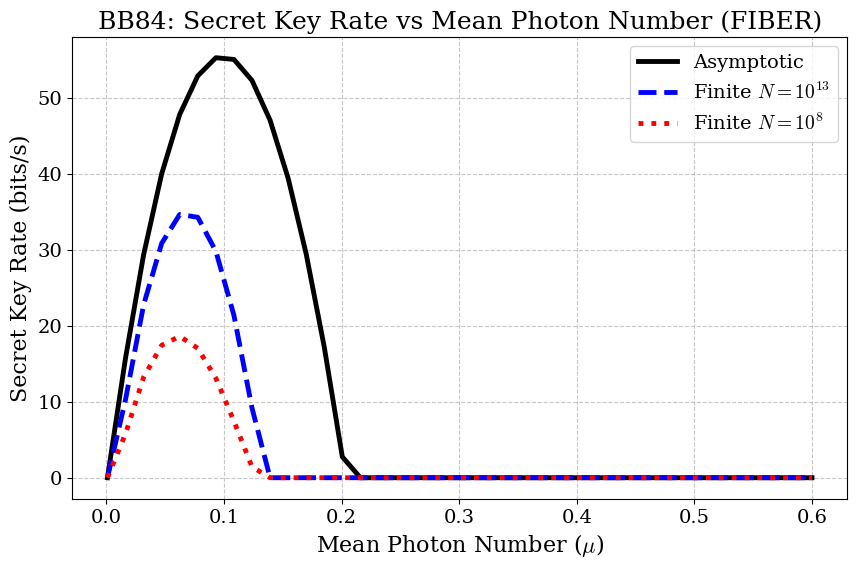

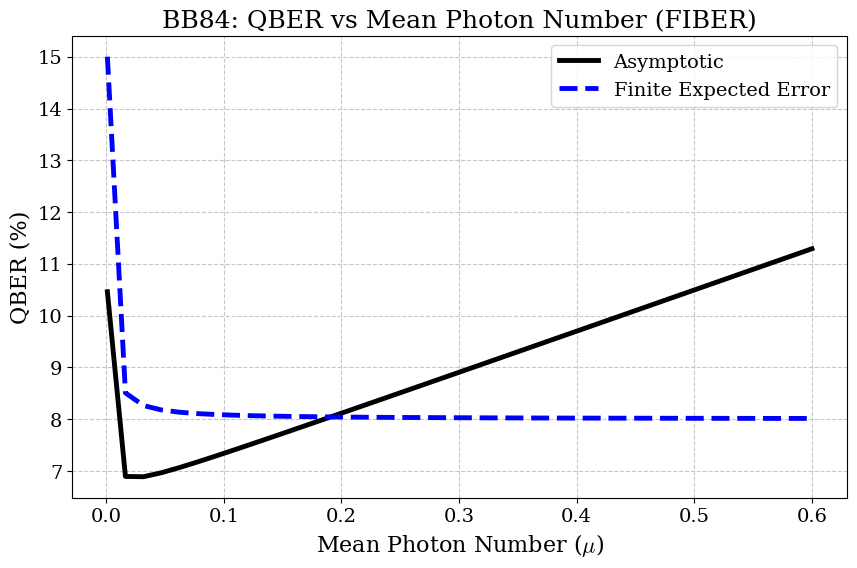

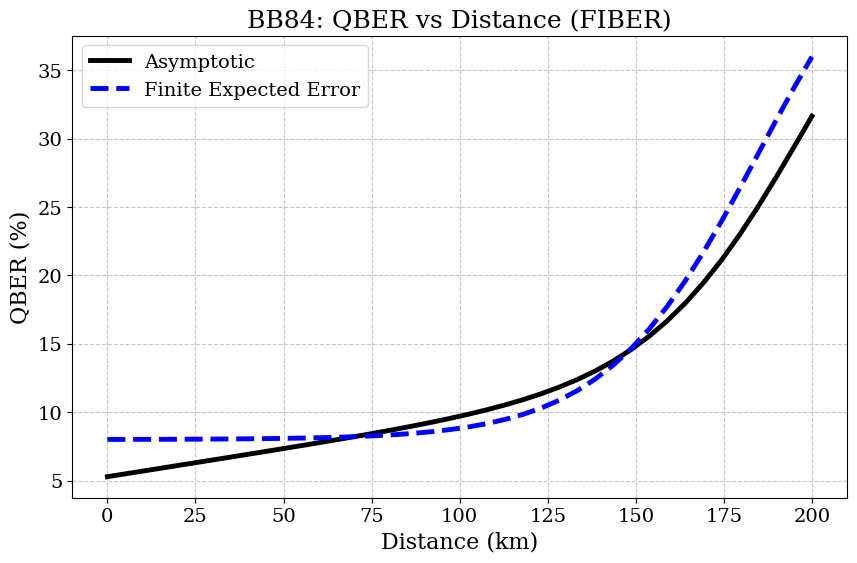

Generating detailed graphs for FSO channel...


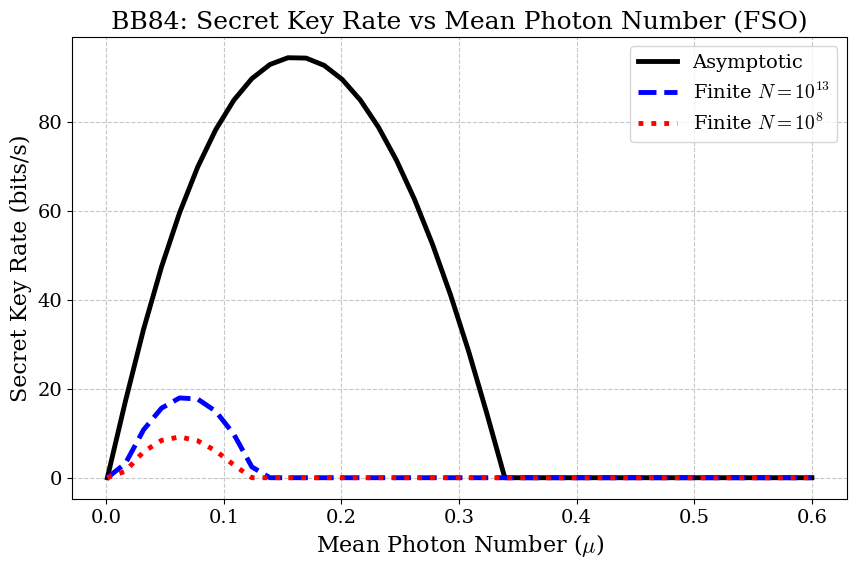

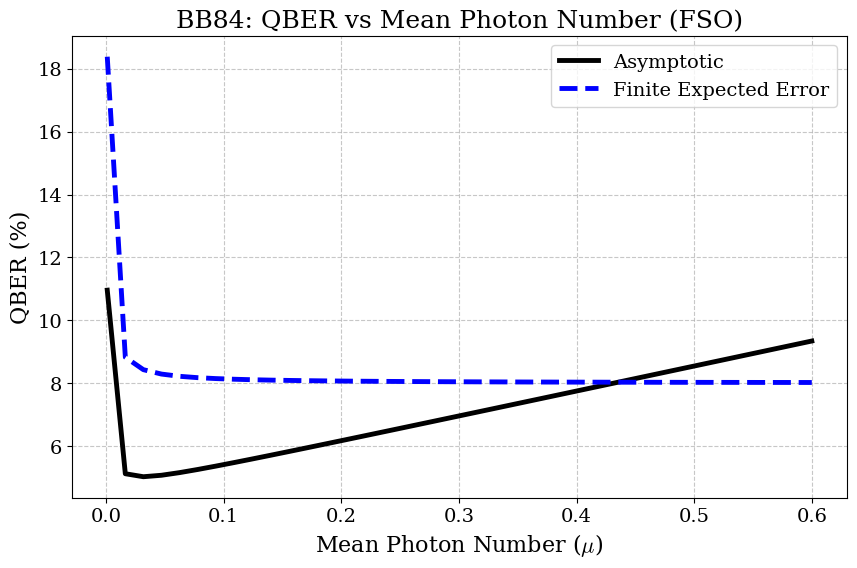

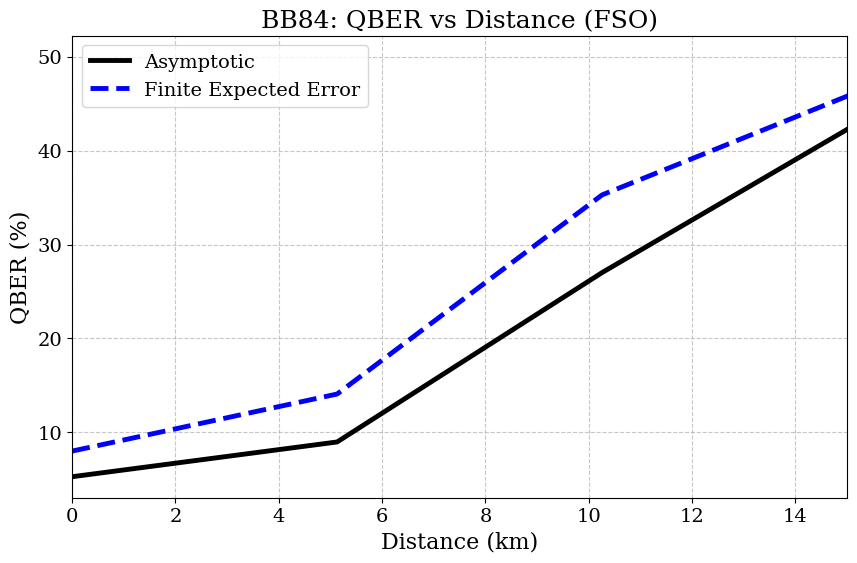

In [3]:
modes = ['fiber', 'fso']

for mode in modes:
    print(f"Generating detailed graphs for {mode.upper()} channel...")
    
    # Store variations
    skr_asym_mu, qber_asym_mu = [], []
    skr_fin_mu_N1, qber_fin_mu_N1 = [], []
    skr_fin_mu_N2, qber_fin_mu_N2 = [], []
    
    # Init Setup
    asym_bb84 = BB84_Asymptotic(
        mu=0.1,
        detector_efficiency=COMMON_PARAMS['eta_det'],
        channel_base_efficiency=1.0,
        dark_count_rate=COMMON_PARAMS['dark_count_hz'],
        time_window=COMMON_PARAMS['time_window'],
        attenuation=COMMON_PARAMS['alpha'],
        channel_mode=mode,
        atmos_attenuation=COMMON_PARAMS['atmos_attenuation'],
        transmitter_diameter=COMMON_PARAMS['transmitter_diameter'],
        receiver_diameter=COMMON_PARAMS['receiver_diameter'],
        beam_divergence=COMMON_PARAMS['beam_divergence'],
        misalignment_base=0.015,
        misalignment_factor=0.0004,
        ec_eff_factor=COMMON_PARAMS['f_ec']
    )

    fin_source = Source(freq=COMMON_PARAMS['repetition_rate'], mean_photon_num=0.1, q=1.0, alignment_error=0.080)
    fin_detector = FiniteDetector(efficiency=COMMON_PARAMS['eta_det'], dark_count_rate=COMMON_PARAMS['dark_count_hz'], time_window=COMMON_PARAMS['time_window'])
    fin_channel = FiniteChannel(
        att_db_km=COMMON_PARAMS['alpha'], 
        channel_mode=mode,
        atmos_attenuation=COMMON_PARAMS['atmos_attenuation'],
        transmitter_diameter=COMMON_PARAMS['transmitter_diameter'],
        receiver_diameter=COMMON_PARAMS['receiver_diameter'],
        beam_divergence=COMMON_PARAMS['beam_divergence']
    )
    fin_protocol = BB84_Finite(fin_source, fin_channel, fin_detector, epsilon_sec=COMMON_PARAMS['epsilon_sec'], f_ec=COMMON_PARAMS['f_ec'])

    fixed_distance = 50.0 if mode == 'fiber' else 1.0
    
    # ---------------------------------------------
    # Calculate Data for Mu variations (fixed dist)
    # ---------------------------------------------
    for mu_val in mu_values:
        asym_bb84.update_distance(fixed_distance)
        asym_bb84.update_mu(mu_val)
        asym_bb84.repetition_rate = COMMON_PARAMS['repetition_rate']
        
        skr_asym_mu.append(max(0, asym_bb84.calculate_skr()))
        qber_asym_mu.append(asym_bb84.calculate_quantum_bit_error_rate())

        fin_channel.L = fixed_distance
        fin_source.mu = mu_val
        
        _, fin_qber, _ = fin_protocol.calculate_system_params()
        qber_fin_mu_N1.append(fin_qber * 100)
        qber_fin_mu_N2.append(fin_qber * 100)
        
        skr_fin_mu_N1.append(max(0, fin_protocol.calculate_skr(BLOCK_SIZES[0])[0]))
        skr_fin_mu_N2.append(max(0, fin_protocol.calculate_skr(BLOCK_SIZES[1])[0]))
        
    skr_asym_dist, qber_asym_dist = [], []
    qber_fin_dist_N1 = []
    
    # ---------------------------------------------
    # Calculate Data for Dist variations (fixed mu)
    # ---------------------------------------------
    for d in distances:
        asym_bb84.update_distance(d)
        asym_bb84.update_mu(COMMON_PARAMS['mu'])
        qber_asym_dist.append(asym_bb84.calculate_quantum_bit_error_rate())
        
        fin_channel.L = d
        fin_source.mu = COMMON_PARAMS['mu']
        _, fin_qber_dist, _ = fin_protocol.calculate_system_params()
        qber_fin_dist_N1.append(fin_qber_dist * 100)

    # ---------------------------------------------
    # Visualization: Plot 1 
    # ---------------------------------------------
    plt.figure(figsize=(10, 6))
    plt.plot(mu_values, skr_asym_mu, 'k-', linewidth=3.5, label='Asymptotic')
    plt.plot(mu_values, skr_fin_mu_N2, 'b--', linewidth=3.5, label=f'Finite $N={BLOCK_LABELS[1]}$')
    plt.plot(mu_values, skr_fin_mu_N1, 'r:', linewidth=3.5, label=f'Finite $N={BLOCK_LABELS[0]}$')
    plt.title(f'BB84: Secret Key Rate vs Mean Photon Number ({mode.upper()})', fontsize=18)
    plt.xlabel(r'Mean Photon Number ($\mu$)', fontsize=16)
    plt.ylabel('Secret Key Rate (bits/s)', fontsize=16)
    y_max = max(skr_asym_mu) if max(skr_asym_mu) > 0 else 1000
    #plt.ylim(0, y_max * 1.1)  # Natively linear for Bell Curve visibility
    plt.grid(True, which="both", ls="--", alpha=0.7)
    plt.legend(fontsize=14)
    plt.show()

    # ---------------------------------------------
    # Visualization: Plot 2 -> QBER vs Mu
    # ---------------------------------------------
    plt.figure(figsize=(10, 6))
    plt.plot(mu_values, qber_asym_mu, 'k-', linewidth=3.5, label='Asymptotic')
    plt.plot(mu_values, qber_fin_mu_N2, 'b--', linewidth=3.5, label='Finite Expected Error')
    plt.title(f'BB84: QBER vs Mean Photon Number ({mode.upper()})', fontsize=18)
    plt.xlabel(r'Mean Photon Number ($\mu$)', fontsize=16)
    plt.ylabel('QBER (%)', fontsize=16)
    #plt.ylim(0, max(max(qber_asym_mu), max(qber_fin_mu_N2)) * 1.2)
    plt.grid(True, which="both", ls="--", alpha=0.7)
    plt.legend(fontsize=14)
    plt.show()

    # ---------------------------------------------
    # Visualization: Plot 3 -> QBER vs Distance
    # ---------------------------------------------
    plt.figure(figsize=(10, 6))
    plt.plot(distances, qber_asym_dist, 'k-', linewidth=3.5, label='Asymptotic')
    plt.plot(distances, qber_fin_dist_N1, 'b--', linewidth=3.5, label='Finite Expected Error')
    plt.title(f'BB84: QBER vs Distance ({mode.upper()})', fontsize=18)
    plt.xlabel('Distance (km)', fontsize=16)
    plt.ylabel('QBER (%)', fontsize=16)
    if mode == 'fso':
        plt.xlim(0, 15)
    #plt.ylim(0, 20)
    plt.grid(True, which="both", ls="--", alpha=0.7)
    plt.legend(fontsize=14)
    plt.show()

## 3. COW Protocol Assessment

The Coherent One-Way (COW) protocol relies on the distribution of coherent states and uses time-bin encoding to mitigate photon number splitting attacks. The finite-key analysis incorporates the probability of different pulse sequences and accounts for phase error estimation from the detection counts. Here we compare its performance under asymptotic and finite constraints.

Generating Asymptotic COW graphs for FIBER channel...


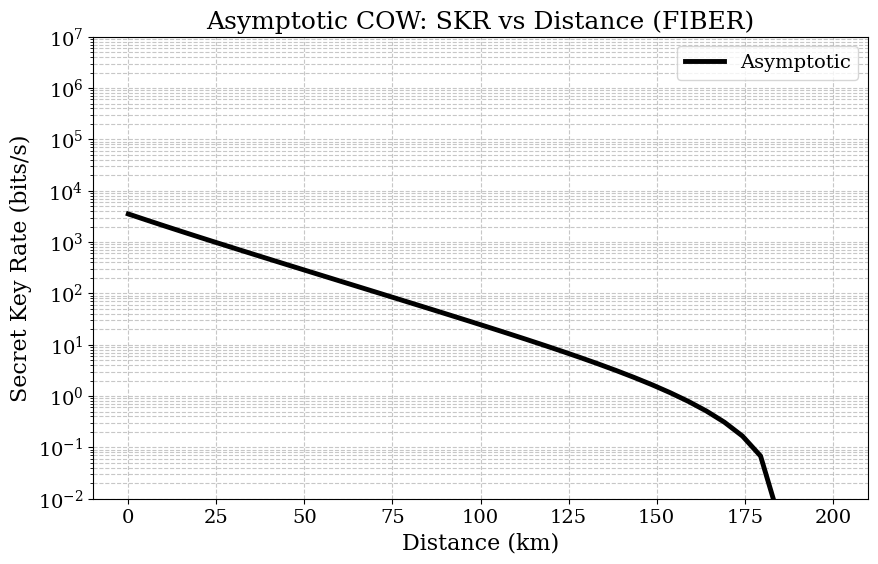

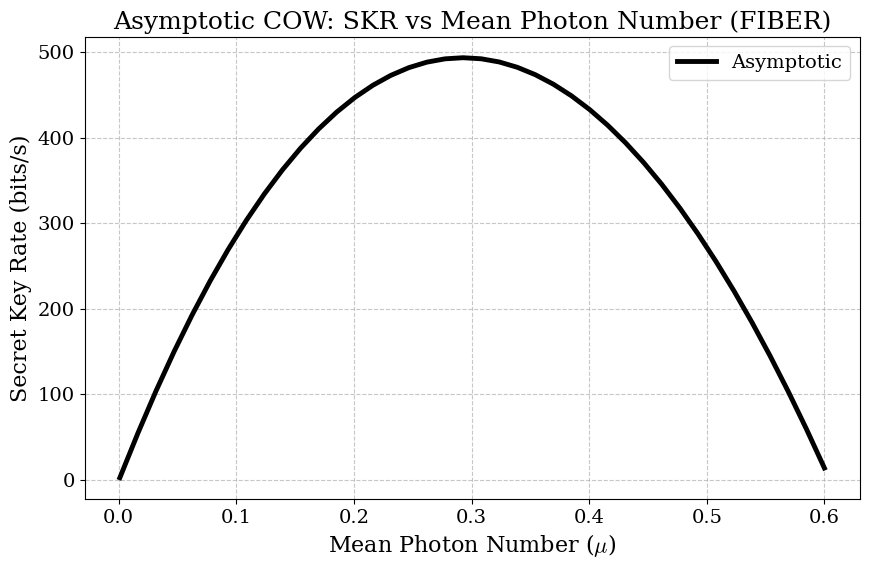

Generating Asymptotic COW graphs for FSO channel...


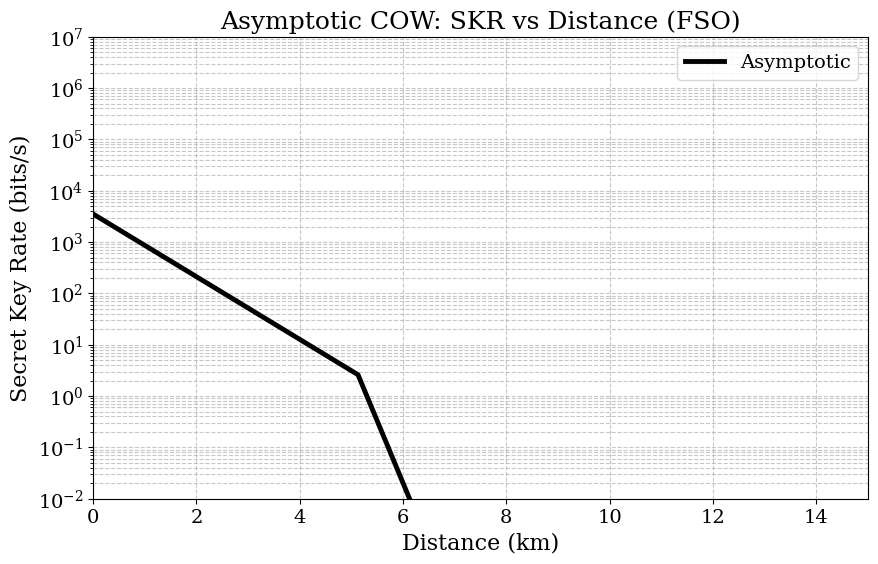

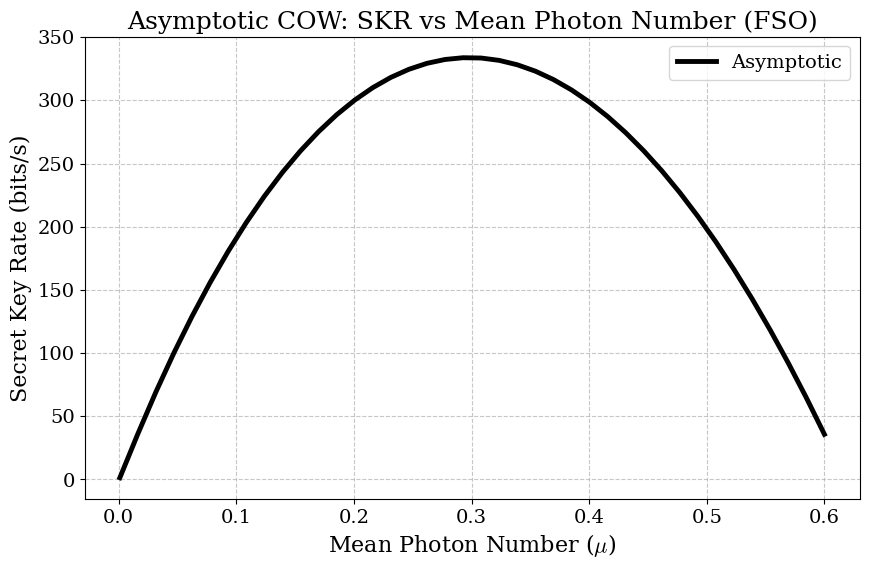

In [4]:
# Import COW asymptotic simulators
from ThOPqkdsim.simCOW import COWProtocol as COW_Asymptotic

modes = ['fiber', 'fso']

# Global dictionaries to store plotting data for comparison in later cells
asym_data = {'fiber': {}, 'fso': {}}

for mode in modes:
    print(f"Generating Asymptotic COW graphs for {mode.upper()} channel...")
    
    skr_asym_mu, qber_asym_mu = [], []
    skr_asym_dist, qber_asym_dist = [], []

    fixed_distance = 50.0 if mode == 'fiber' else 1.0
    fso_dict = {
        'transmitter_diameter': COMMON_PARAMS['transmitter_diameter'],
        'receiver_diameter': COMMON_PARAMS['receiver_diameter'],
        'beam_divergence': COMMON_PARAMS['beam_divergence'],
        'atmos_attenuation': COMMON_PARAMS['atmos_attenuation']
    } if mode == 'fso' else None

    # ---------------------------------------------
    # Calculate Data for Mu variations (fixed dist)
    # ---------------------------------------------
    for mu_val in mu_values:
        asym_cow = COW_Asymptotic(
            mu=mu_val, distance=fixed_distance, detector_efficiency=COMMON_PARAMS['eta_det'],
            dark_count_rate=COMMON_PARAMS['dark_count_hz'], time_window=COMMON_PARAMS['time_window'],
            channel_base_efficiency=1.0, attenuation=COMMON_PARAMS['alpha'], channel_mode=mode,
            data_line_ratio=0.9, decoy_probability=0.1, error_correction_efficiency=COMMON_PARAMS['f_ec'],
            interference_visibility=0.995, repetition_rate=COMMON_PARAMS['repetition_rate']
        )
        if mode == 'fso': asym_cow.set_fso_parameters(**fso_dict)
            
        skr_asym_mu.append(max(0, asym_cow.calculate_skr()))
        qber_asym_mu.append(asym_cow.calculate_qber())

    # ---------------------------------------------
    # Calculate Data for Dist variations (fixed mu)
    # ---------------------------------------------
    for d in distances:
        asym_cow_d = COW_Asymptotic(
            mu=COMMON_PARAMS['mu'], distance=d, detector_efficiency=COMMON_PARAMS['eta_det'],
            dark_count_rate=COMMON_PARAMS['dark_count_hz'], time_window=COMMON_PARAMS['time_window'],
            channel_base_efficiency=1.0, attenuation=COMMON_PARAMS['alpha'], channel_mode=mode,
            data_line_ratio=0.9, decoy_probability=0.1, error_correction_efficiency=COMMON_PARAMS['f_ec'],
            interference_visibility=0.995, repetition_rate=COMMON_PARAMS['repetition_rate']
        )
        if mode == 'fso': asym_cow_d.set_fso_parameters(**fso_dict)
            
        skr_asym_dist.append(max(1e-12, asym_cow_d.calculate_skr()))
        qber_asym_dist.append(asym_cow_d.calculate_qber())

    asym_data[mode] = {'skr_dist': skr_asym_dist, 'skr_mu': skr_asym_mu}

    # ---------------------------------------------
    # SKR vs Distance Plot
    # ---------------------------------------------
    plt.figure(figsize=(10, 6))
    plt.semilogy(distances, skr_asym_dist, 'k-', linewidth=3.5, label='Asymptotic')
    plt.title(f'Asymptotic COW: SKR vs Distance ({mode.upper()})', fontsize=18)
    plt.xlabel('Distance (km)', fontsize=16); plt.ylabel('Secret Key Rate (bits/s)', fontsize=16)
    if mode == 'fso': plt.xlim(0, 15)
    plt.ylim(1e-2, 1e7); plt.grid(True, which="both", ls="--", alpha=0.7); plt.legend(); plt.show()
    
    # ---------------------------------------------
    # SKR vs Mu Plot
    # ---------------------------------------------
    plt.figure(figsize=(10, 6))
    plt.plot(mu_values, skr_asym_mu, 'k-', linewidth=3.5, label='Asymptotic')
    plt.title(f'Asymptotic COW: SKR vs Mean Photon Number ({mode.upper()})', fontsize=18)
    plt.xlabel(r'Mean Photon Number ($\mu$)', fontsize=16); plt.ylabel('Secret Key Rate (bits/s)', fontsize=16)
    plt.grid(True, which="both", ls="--", alpha=0.7); plt.legend(); plt.show()

Generating Finite COW graphs exclusively...


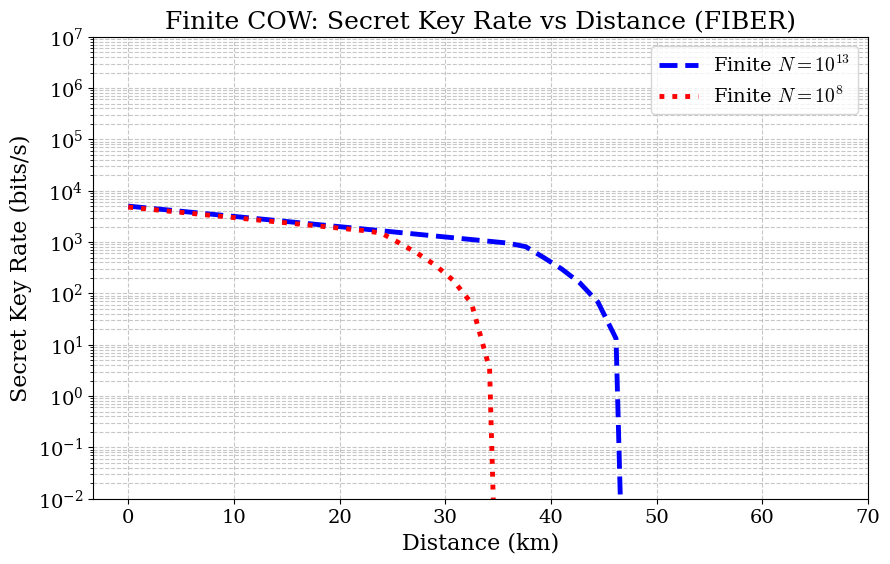

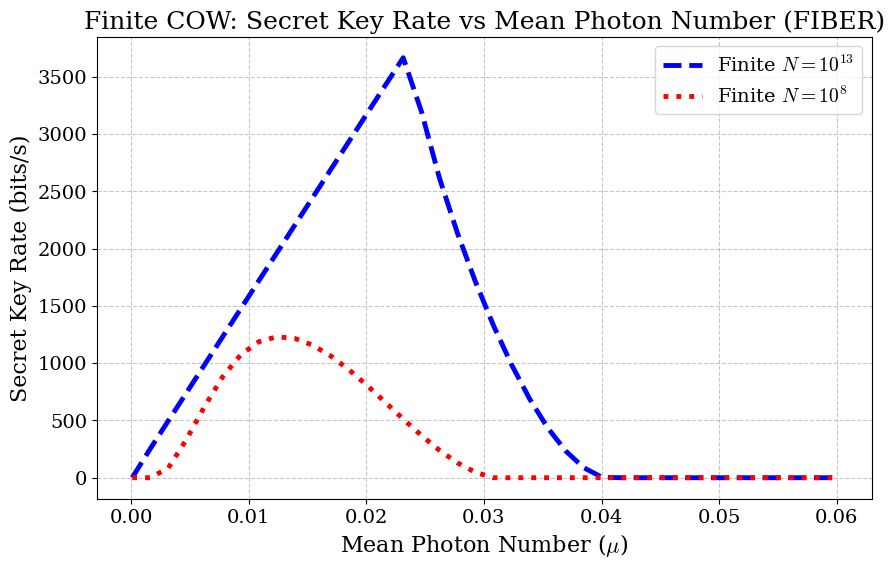

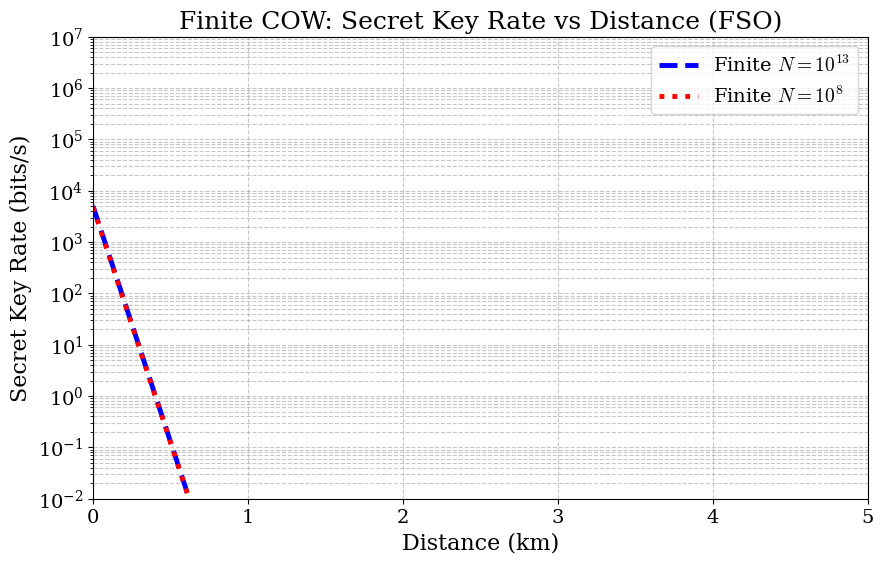

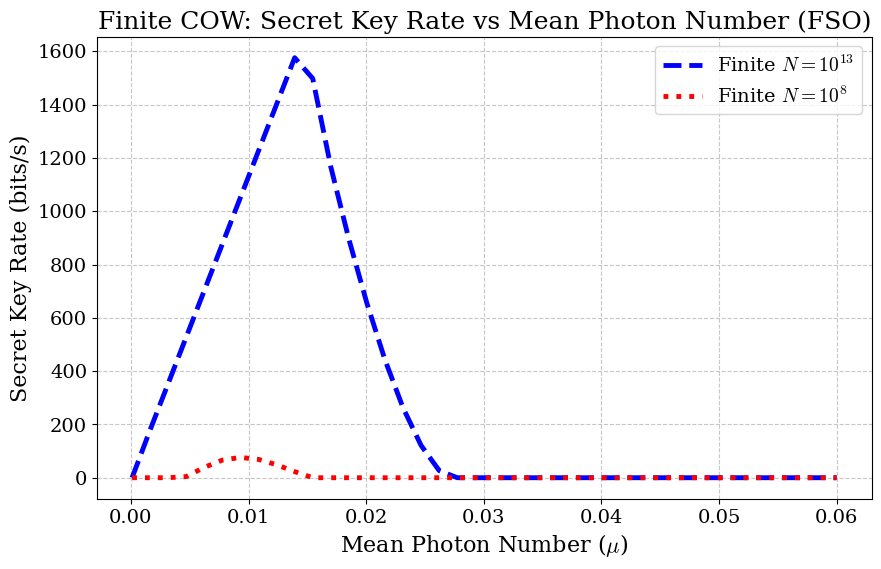

In [5]:
# Import COW finite key simulator
from ThOPqkdsim.cow_finite_key import COWSimulator as COW_Finite

print("Generating Finite COW graphs exclusively...")

# Scaled test spaces to reflect the rigorous constraints of Finite COW (1/3 scale dist, 1/10 scale mu)
distances_fin = distances / 3.0
mu_values_fin = np.linspace(0.0001, COMMON_PARAMS['mu'] * 0.6, 40) # Focus up to 0.06

fin_data = {'fiber': {}, 'fso': {}}

for mode in modes:
    skr_fin_mu_N1, qber_fin_mu_N1 = [], []
    skr_fin_mu_N2, qber_fin_mu_N2 = [], []
    skr_fin_dist_N1, qber_fin_dist_N1 = [], []
    skr_fin_dist_N2, qber_fin_dist_N2 = [], []

    fixed_distance = 25.0 if mode == 'fiber' else 0.5
    optimal_fin_mu = 0.01 # Heavily restricted optimal mu to suppress the finite phase error bounds
    fso_dict = {
        'transmitter_diameter': COMMON_PARAMS['transmitter_diameter'],
        'receiver_diameter': COMMON_PARAMS['receiver_diameter'],
        'beam_divergence': COMMON_PARAMS['beam_divergence'],
        'atmos_attenuation': COMMON_PARAMS['atmos_attenuation']
    } if mode == 'fso' else None

    # ---------------------------------------------
    # Calculate Data for Mu variations
    # ---------------------------------------------
    for mu_val in mu_values_fin:
        fin_cow = COW_Finite(
            distance_km=fixed_distance, mu=mu_val, mode=mode, fso_params=fso_dict,
            data_line_ratio=0.9, eta_d0=0.8, eta_d1=0.8, eta_d2=0.8,
            dark_count_d0_hz=COMMON_PARAMS['dark_count_hz'], dark_count_d1_hz=COMMON_PARAMS['dark_count_hz'], dark_count_d2_hz=COMMON_PARAMS['dark_count_hz'],
            freq=COMMON_PARAMS['repetition_rate'], time_window=COMMON_PARAMS['time_window'],
            f_ec=COMMON_PARAMS['f_ec'], visibility=0.995, attenuation=COMMON_PARAMS['alpha'], epsilon_sec=COMMON_PARAMS['epsilon_sec']
        )
        r1, q1, _ = fin_cow.compute_skr(BLOCK_SIZES[0])
        r2, q2, _ = fin_cow.compute_skr(BLOCK_SIZES[1])
        skr_fin_mu_N1.append(max(0, r1)); skr_fin_mu_N2.append(max(0, r2))

    # ---------------------------------------------
    # Calculate Data for Dist variations
    # ---------------------------------------------
    for d in distances_fin:
        fin_cow_d = COW_Finite(
            distance_km=d, mu=optimal_fin_mu, mode=mode, fso_params=fso_dict,
            data_line_ratio=0.9, eta_d0=0.8, eta_d1=0.8, eta_d2=0.8,
            dark_count_d0_hz=COMMON_PARAMS['dark_count_hz'], dark_count_d1_hz=COMMON_PARAMS['dark_count_hz'], dark_count_d2_hz=COMMON_PARAMS['dark_count_hz'],
            freq=COMMON_PARAMS['repetition_rate'], time_window=COMMON_PARAMS['time_window'],
            f_ec=COMMON_PARAMS['f_ec'], visibility=0.995, attenuation=COMMON_PARAMS['alpha'], epsilon_sec=COMMON_PARAMS['epsilon_sec']
        )
        r1, q1, _ = fin_cow_d.compute_skr(BLOCK_SIZES[0])
        r2, q2, _ = fin_cow_d.compute_skr(BLOCK_SIZES[1])
        skr_fin_dist_N1.append(max(1e-12, r1)); skr_fin_dist_N2.append(max(1e-12, r2))

    fin_data[mode] = {'skr_dist_N1': skr_fin_dist_N1, 'skr_dist_N2': skr_fin_dist_N2, 'skr_mu_N1': skr_fin_mu_N1, 'skr_mu_N2': skr_fin_mu_N2}

    # ---------------------------------------------
    # SKR vs Distance Plot
    # ---------------------------------------------
    plt.figure(figsize=(10, 6))
    plt.semilogy(distances_fin, skr_fin_dist_N2, 'b--', linewidth=3.5, label=f'Finite $N={BLOCK_LABELS[1]}$')
    plt.semilogy(distances_fin, skr_fin_dist_N1, 'r:', linewidth=3.5, label=f'Finite $N={BLOCK_LABELS[0]}$')
    plt.title(f'Finite COW: Secret Key Rate vs Distance ({mode.upper()})', fontsize=18)
    plt.xlabel('Distance (km)', fontsize=16); plt.ylabel('Secret Key Rate (bits/s)', fontsize=16)
    if mode == 'fso': plt.xlim(0, 15/3.0)
    plt.ylim(1e-2, 1e7); plt.grid(True, which="both", ls="--", alpha=0.7); plt.legend(); plt.show()
    
    # ---------------------------------------------
    # SKR vs Mu Plot
    # ---------------------------------------------
    plt.figure(figsize=(10, 6))
    plt.plot(mu_values_fin, skr_fin_mu_N2, 'b--', linewidth=3.5, label=f'Finite $N={BLOCK_LABELS[1]}$')
    plt.plot(mu_values_fin, skr_fin_mu_N1, 'r:', linewidth=3.5, label=f'Finite $N={BLOCK_LABELS[0]}$')
    plt.title(f'Finite COW: Secret Key Rate vs Mean Photon Number ({mode.upper()})', fontsize=18)
    plt.xlabel(r'Mean Photon Number ($\mu$)', fontsize=16); plt.ylabel('Secret Key Rate (bits/s)', fontsize=16)
    plt.grid(True, which="both", ls="--", alpha=0.7); plt.legend(); plt.show()

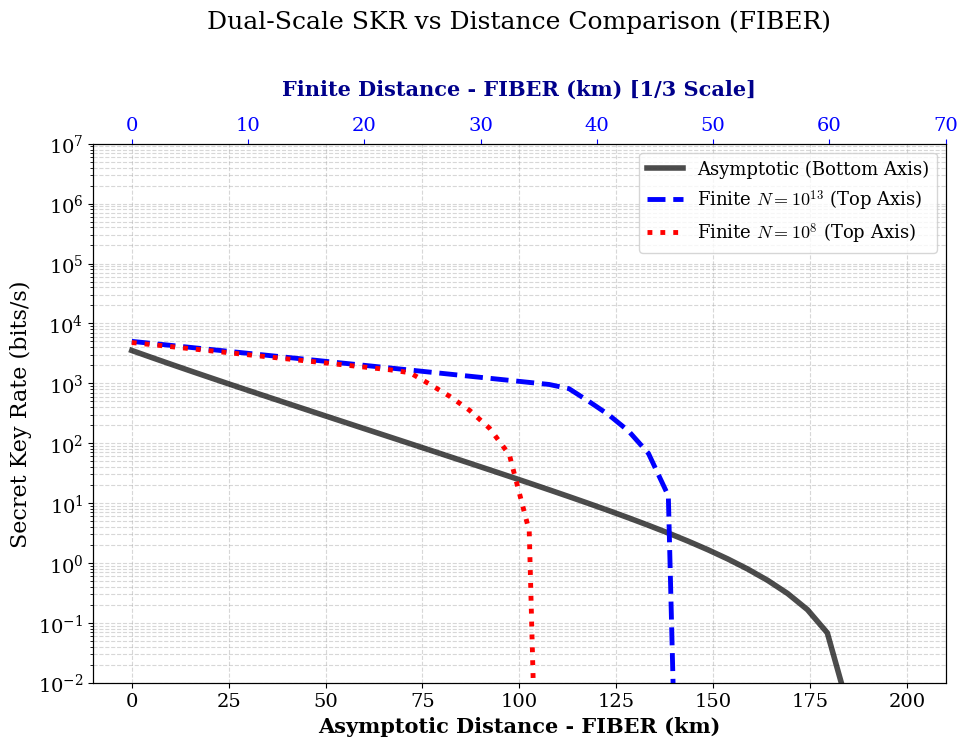

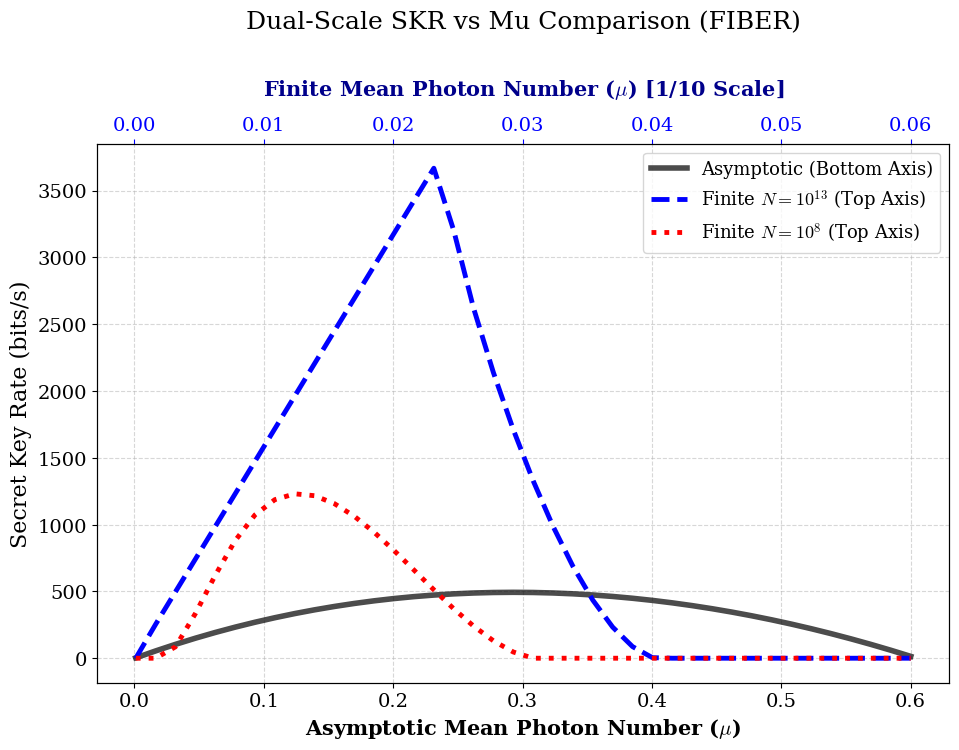

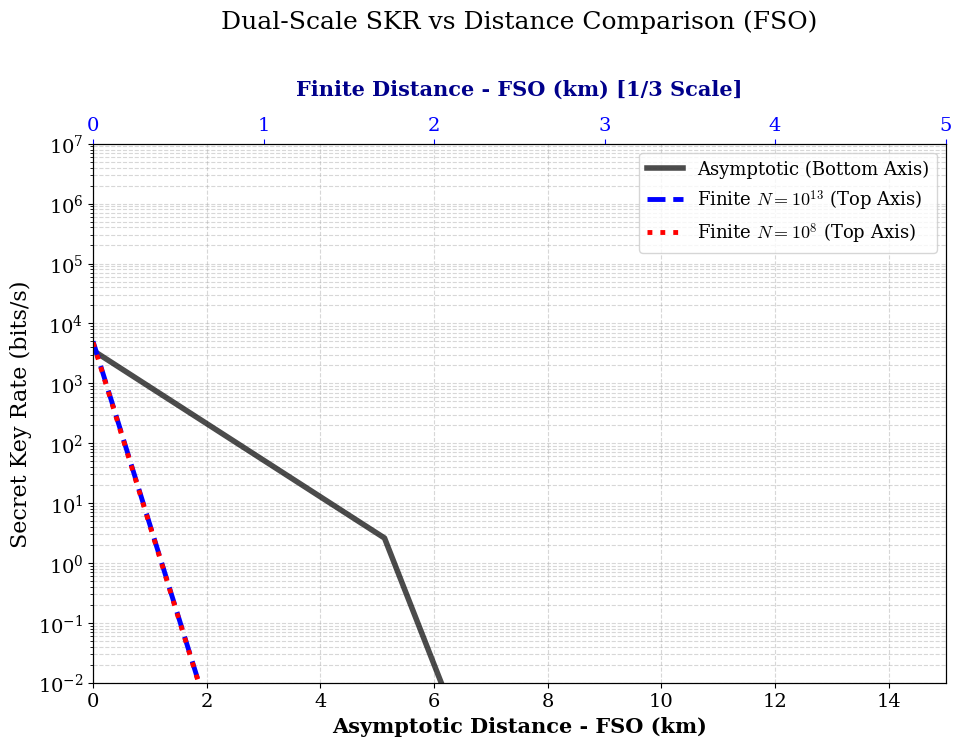

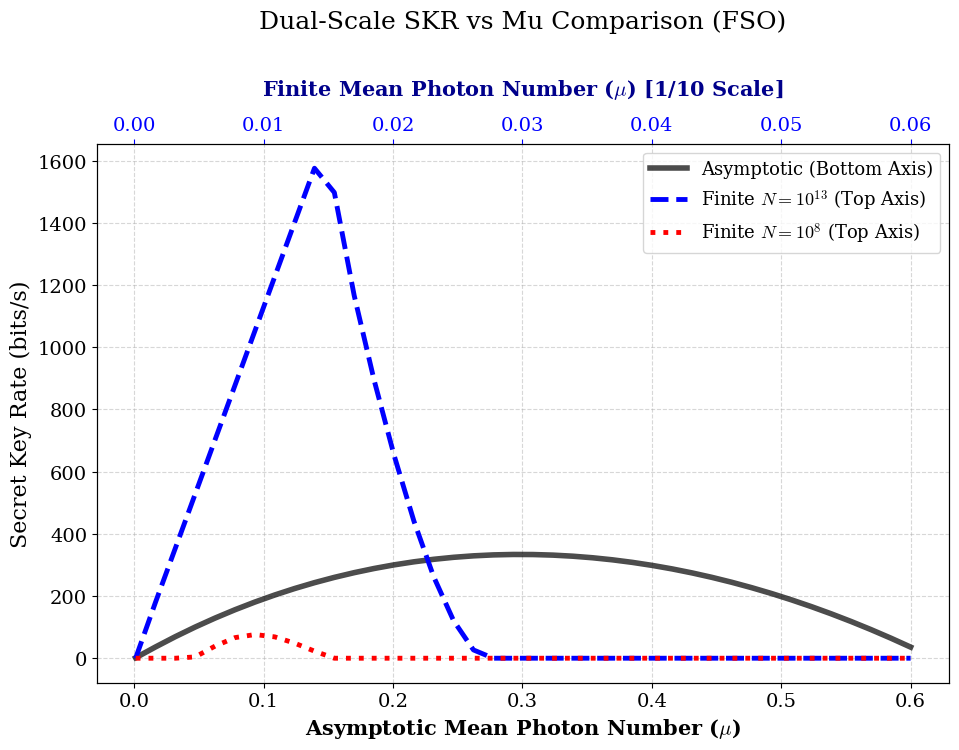

In [6]:
# -------------------------------------------------------------
# Advanced Visualization: Combining Asymptotic and Finite COW
# Using Dual-X Axes to contrast differing bounds
# -------------------------------------------------------------

for mode in modes:
    # 1. Combined Distance Plot
    fig, ax1 = plt.subplots(figsize=(11, 7))
    ax2 = ax1.twiny() # Create a twin X-axis sharing the Y-axis

    # Plot Asymptotic
    ax1.semilogy(distances, asym_data[mode]['skr_dist'], 'k-', linewidth=4, alpha=0.7, label='Asymptotic (Bottom Axis)')
    ax1.set_xlabel(f'Asymptotic Distance - {mode.upper()} (km)', fontsize=15, color='k', weight='bold')
    ax1.set_ylabel('Secret Key Rate (bits/s)', fontsize=16)
    ax1.tick_params(axis='x', colors='k', labelsize=14)
    ax1.tick_params(axis='y', labelsize=14)
    if mode == 'fso': ax1.set_xlim(0, 15)
    ax1.set_ylim(1e-2, 1e7)
    
    # Plot Finite 
    ax2.semilogy(distances_fin, fin_data[mode]['skr_dist_N2'], 'b--', linewidth=3.5, label=f'Finite $N={BLOCK_LABELS[1]}$ (Top Axis)')
    ax2.semilogy(distances_fin, fin_data[mode]['skr_dist_N1'], 'r:', linewidth=3.5, label=f'Finite $N={BLOCK_LABELS[0]}$ (Top Axis)')
    ax2.set_xlabel(f'Finite Distance - {mode.upper()} (km) [1/3 Scale]', fontsize=15, color='darkblue', weight='bold', labelpad=15)
    ax2.tick_params(axis='x', colors='b', labelsize=14)
    if mode == 'fso': ax2.set_xlim(0, 5) # 1/3 of asymptotic FSO

    plt.title(f'Dual-Scale SKR vs Distance Comparison ({mode.upper()})', fontsize=18, y=1.2)
    
    # Combine legends into one box
    lines_1, labels_1 = ax1.get_legend_handles_labels()
    lines_2, labels_2 = ax2.get_legend_handles_labels()
    ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper right', fontsize=13)
    ax1.grid(True, which="both", ls="--", alpha=0.5)
    plt.show()

    # 2. Combined Mu Plot
    fig, ax1 = plt.subplots(figsize=(11, 7))
    ax2 = ax1.twiny()

    # Plot Asymptotic
    ax1.plot(mu_values, asym_data[mode]['skr_mu'], 'k-', linewidth=4, alpha=0.7, label='Asymptotic (Bottom Axis)')
    ax1.set_xlabel(r'Asymptotic Mean Photon Number ($\mu$)', fontsize=15, color='k', weight='bold')
    ax1.set_ylabel('Secret Key Rate (bits/s)', fontsize=16)
    ax1.tick_params(axis='x', colors='k', labelsize=14)
    ax1.tick_params(axis='y', labelsize=14)

    # Plot Finite 
    ax2.plot(mu_values_fin, fin_data[mode]['skr_mu_N2'], 'b--', linewidth=3.5, label=f'Finite $N={BLOCK_LABELS[1]}$ (Top Axis)')
    ax2.plot(mu_values_fin, fin_data[mode]['skr_mu_N1'], 'r:', linewidth=3.5, label=f'Finite $N={BLOCK_LABELS[0]}$ (Top Axis)')
    ax2.set_xlabel(r'Finite Mean Photon Number ($\mu$) [1/10 Scale]', fontsize=15, color='darkblue', weight='bold', labelpad=15)
    ax2.tick_params(axis='x', colors='b', labelsize=14)

    plt.title(f'Dual-Scale SKR vs Mu Comparison ({mode.upper()})', fontsize=18, y=1.2)
    
    # Combine legends into one box
    lines_1, labels_1 = ax1.get_legend_handles_labels()
    lines_2, labels_2 = ax2.get_legend_handles_labels()
    ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper right', fontsize=13)
    ax1.grid(True, which="both", ls="--", alpha=0.5)
    plt.show()

## 4. DPS Protocol Assessment

The Differential Phase Shift (DPS) protocol measures phase differences between sequential pulses. In the finite regime, parameter estimation for privacy amplification is performed under the constraint of finite key sizes and the lack of independent bounds for error estimation across multiple uncoupled runs. Here we contrast the theoretical performance bounds defined by theoretical DPS simulations to rigorously derived finite-key size scaling operations.

Generating Asymptotic vs Finite DPS Comparison graphs...

--- Processing FIBER Channel ---


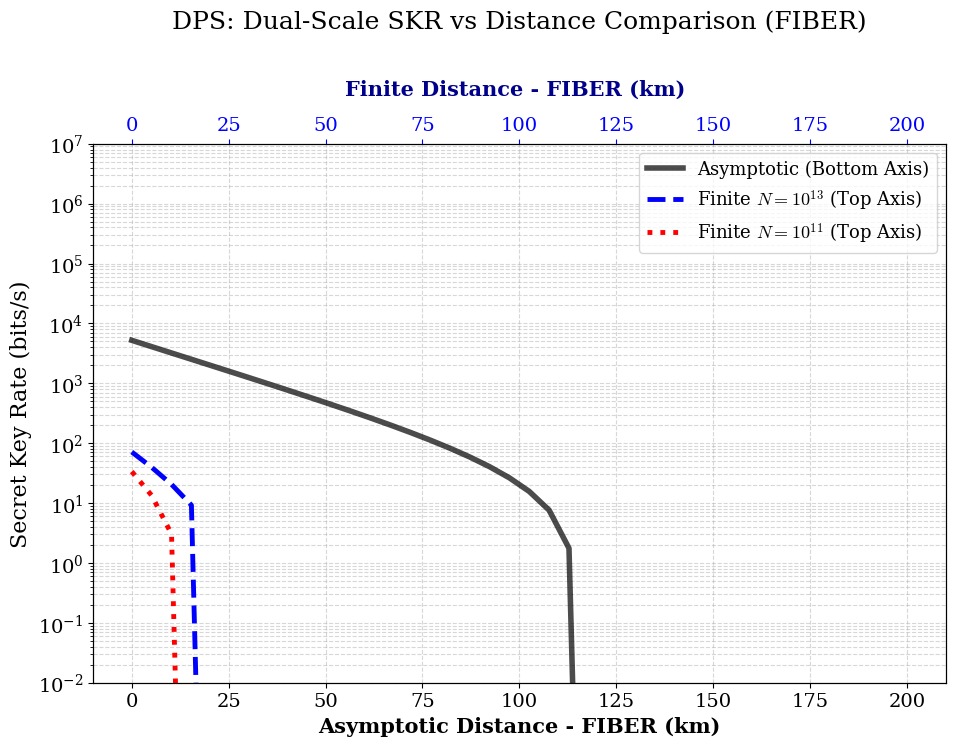

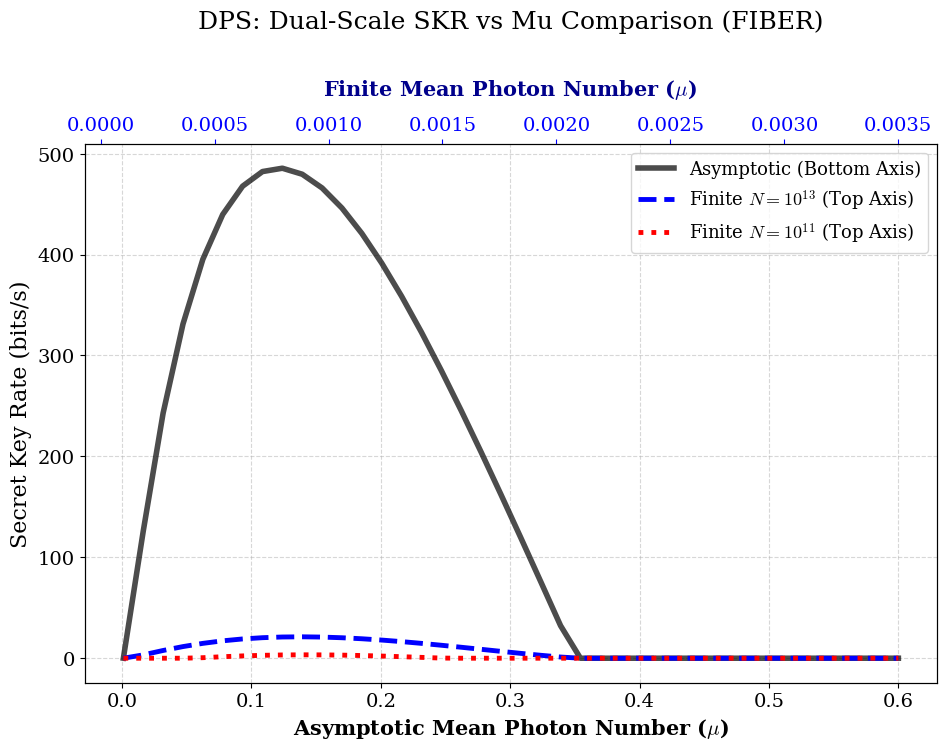


--- Processing FSO Channel ---


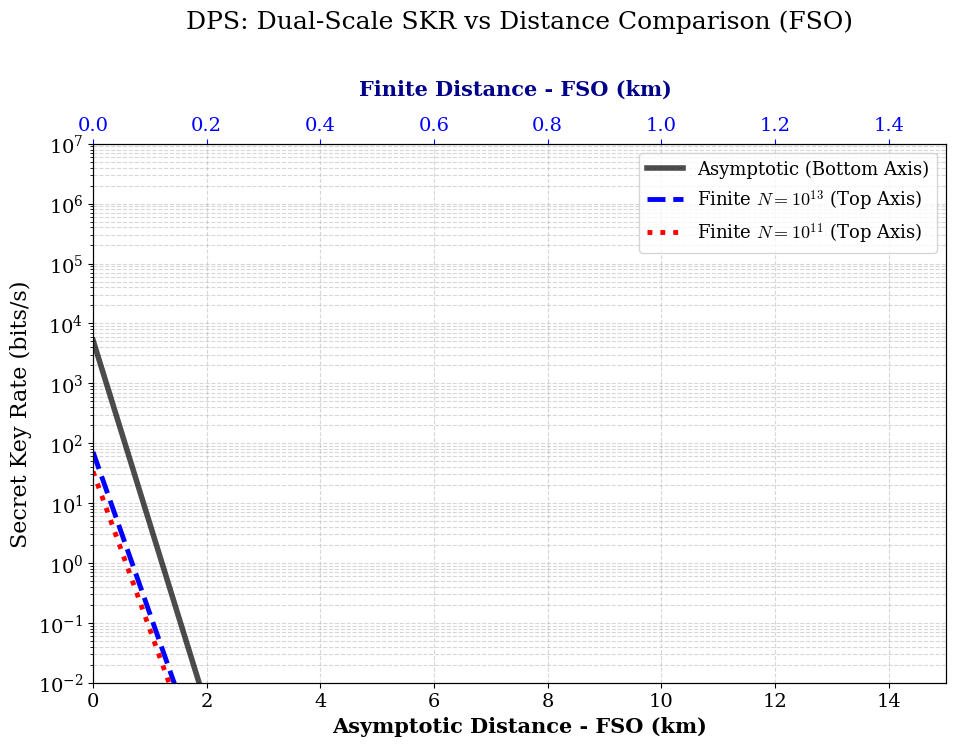

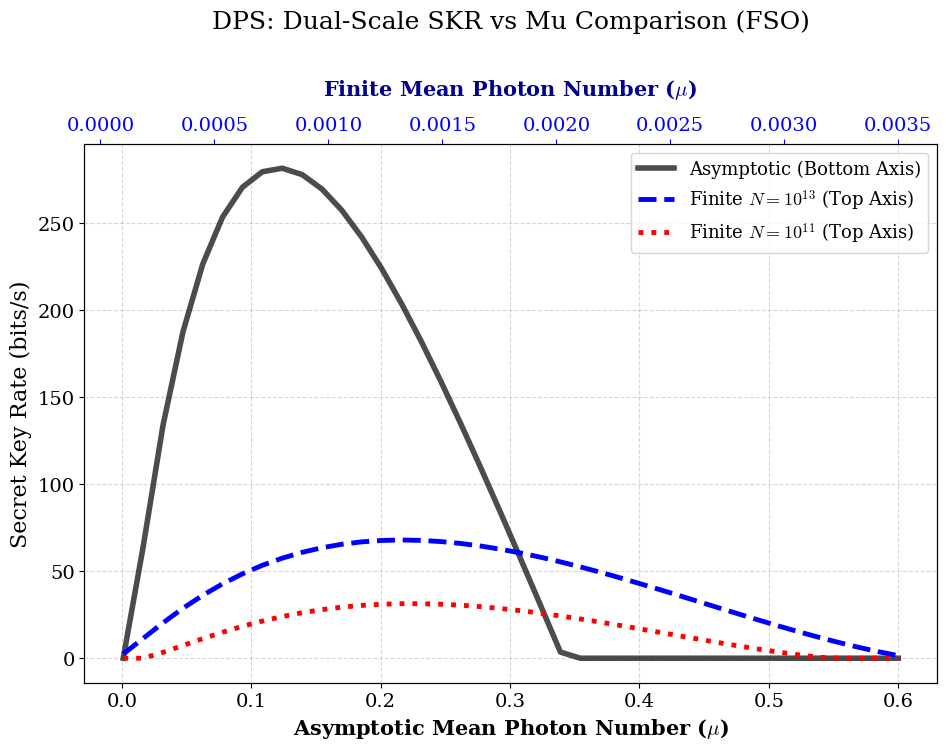

In [7]:
# Import DPS Simulators
from ThOPqkdsim.simDPS import DPSQKDSimulator as DPS_Asymptotic
from ThOPqkdsim.DPS_finite import DPSProtocol as DPS_Finite,IdealSinglePhotonSource, CoherentSource, Channel as FiniteChannel, Detector as FiniteDetector
from scipy.optimize import minimize_scalar, minimize
import numpy as np
import matplotlib.pyplot as plt

def get_optimized_fin_skr_2d(protocol):
    """
    Optimizes both mu and t for the finite DPS protocol using the physically accurate CoherentSource.
    """
    res = minimize(
        lambda x: -protocol.calculate_skr(x), 
        x0=[0.001, 0.8], 
        bounds=[(1e-4, 0.005), (0.5, 0.95)], 
        method='L-BFGS-B'
    )
    val = -res.fun
    return val if val > 1e-10 else 0.0

def get_optimized_fin_skr_t(protocol, mu_fixed):
    res = minimize_scalar(
        lambda t: -protocol.calculate_skr([mu_fixed, t]), 
        bounds=(0.1, 0.95), 
        method='bounded'
    )
    val = -res.fun
    return val if val > 1e-10 else 0.0

print("Generating Asymptotic vs Finite DPS Comparison graphs...")

modes = ['fiber', 'fso']

# Narrowed bounds specifically where Finite DPS survives Kato's multi-photon constraints 
mu_values_fin = np.linspace(0.0001, 0.0035, 40)
BLOCK_SIZES = [1e11, 1e13] 
BLOCK_LABELS = ["10^{11}", "10^{13}"]

for mode in modes:
    print(f"\n--- Processing {mode.upper()} Channel ---")
    
    # Scale distances_fin severely for FSO due to high attenuation killing bounded keygen
    distances_fin = np.linspace(0, 200, 40) if mode == 'fiber' else np.linspace(0, 20, 40)
    
    skr_asym_mu, skr_fin_mu_N1, skr_fin_mu_N2 = [], [], []
    skr_asym_dist, skr_fin_dist_N1, skr_fin_dist_N2 = [], [], []

    fixed_distance = 50.0 if mode == 'fiber' else 1.0
    fin_fixed_dist = 10.0 if mode == 'fiber' else 0.1
    
    fso_kwargs = {
        'transmitter_diameter': COMMON_PARAMS['transmitter_diameter'],
        'receiver_diameter': COMMON_PARAMS['receiver_diameter'],
        'beam_divergence': COMMON_PARAMS['beam_divergence'],
        'atmos_attenuation': COMMON_PARAMS['atmos_attenuation']
    } if mode == 'fso' else {}

    # Setup Asymptotic Protocol
    asym_dps = DPS_Asymptotic(
        repetition_rate=COMMON_PARAMS['repetition_rate'],
        mu=COMMON_PARAMS['mu'],
        eta_det=COMMON_PARAMS['eta_det'],
        dark_count=COMMON_PARAMS['dark_count_prob'],
        alpha=COMMON_PARAMS['alpha'],
        distance=fixed_distance,
        channel_mode=mode,
        errcorr_factor=COMMON_PARAMS['f_ec'],
        **fso_kwargs
    )

    # Setup Finite Protocol structure 
    source_fin = CoherentSource()
    channel_fin = FiniteChannel(
        mode=mode, 
        distance_km=fixed_distance, 
        alpha=COMMON_PARAMS['alpha'],
        transmitter_diameter=COMMON_PARAMS.get('transmitter_diameter', 0.1),
        receiver_diameter=COMMON_PARAMS.get('receiver_diameter', 0.3),
        beam_divergence=COMMON_PARAMS.get('beam_divergence', 10e-6),
        atmospheric_attenuation=COMMON_PARAMS.get('atmos_attenuation', 0.0)
    )
    detector_fin = FiniteDetector(
        dark_count_rate=COMMON_PARAMS['dark_count_hz'],
        efficiency=COMMON_PARAMS['eta_det'],
        time_window=COMMON_PARAMS['time_window']
    )

    # 1. Distances Variation 
    for d in distances:
        asym_dps.update_distance(d)
        asym_dps.mu = COMMON_PARAMS['mu']
        skr_a = asym_dps.calculate_secret_key_rate()
        skr_asym_dist.append(max(1e-12, skr_a if skr_a is not None else 1e-12))
        
    for d_fin in distances_fin:
        channel_fin.set_distance(d_fin)
        
        fin_prot_N1 = DPS_Finite(source_fin, channel_fin, detector_fin, n_em=BLOCK_SIZES[0], rep_rate=COMMON_PARAMS['repetition_rate'], epsilon_sec=COMMON_PARAMS['epsilon_sec'], f_ec=COMMON_PARAMS['f_ec'])
        skr_fin_dist_N1.append(max(1e-12, get_optimized_fin_skr_2d(fin_prot_N1)))
        
        fin_prot_N2 = DPS_Finite(source_fin, channel_fin, detector_fin, n_em=BLOCK_SIZES[1], rep_rate=COMMON_PARAMS['repetition_rate'], epsilon_sec=COMMON_PARAMS['epsilon_sec'], f_ec=COMMON_PARAMS['f_ec'])
        skr_fin_dist_N2.append(max(1e-12, get_optimized_fin_skr_2d(fin_prot_N2)))

    # 2. Mu Variation 
    for mu_val in mu_values:
        asym_dps.update_distance(fixed_distance)
        asym_dps.mu = mu_val
        skr_a = asym_dps.calculate_secret_key_rate()
        skr_asym_mu.append(max(0, skr_a if skr_a is not None else 0))

    channel_fin.set_distance(fin_fixed_dist)
    for mu_fin in mu_values_fin:
        fin_prot_N1 = DPS_Finite(source_fin, channel_fin, detector_fin, n_em=BLOCK_SIZES[0], rep_rate=COMMON_PARAMS['repetition_rate'], epsilon_sec=COMMON_PARAMS['epsilon_sec'], f_ec=COMMON_PARAMS['f_ec'])
        skr_fin_mu_N1.append(max(0, get_optimized_fin_skr_t(fin_prot_N1, mu_fin)))

        fin_prot_N2 = DPS_Finite(source_fin, channel_fin, detector_fin, n_em=BLOCK_SIZES[1], rep_rate=COMMON_PARAMS['repetition_rate'], epsilon_sec=COMMON_PARAMS['epsilon_sec'], f_ec=COMMON_PARAMS['f_ec'])
        skr_fin_mu_N2.append(max(0, get_optimized_fin_skr_t(fin_prot_N2, mu_fin)))

    # -------------------------------------------------------------
    # Advanced Visualization: Dual-X Axes exactly mapping parameters
    # -------------------------------------------------------------
    
    #Plot 1: Combined Distance Plot
    fig, ax1 = plt.subplots(figsize=(11, 7))
    ax2 = ax1.twiny()

    ax1.semilogy(distances, skr_asym_dist, 'k-', linewidth=4, alpha=0.7, label='Asymptotic (Bottom Axis)')
    ax1.set_xlabel(f'Asymptotic Distance - {mode.upper()} (km)', fontsize=15, color='k', weight='bold')
    ax1.set_ylabel('Secret Key Rate (bits/s)', fontsize=16)
    ax1.tick_params(axis='x', colors='k', labelsize=14)
    ax1.tick_params(axis='y', labelsize=14)
    if mode == 'fso': ax1.set_xlim(0, 15)
    ax1.set_ylim(1e-2, 1e7)
    
    ax2.semilogy(distances_fin, skr_fin_dist_N2, 'b--', linewidth=3.5, label=f'Finite $N={BLOCK_LABELS[1]}$ (Top Axis)')
    ax2.semilogy(distances_fin, skr_fin_dist_N1, 'r:', linewidth=3.5, label=f'Finite $N={BLOCK_LABELS[0]}$ (Top Axis)')
    ax2.set_xlabel(f'Finite Distance - {mode.upper()} (km) ', fontsize=15, color='darkblue', weight='bold', labelpad=15)
    ax2.tick_params(axis='x', colors='b', labelsize=14)
    if mode == 'fso': ax2.set_xlim(0, 1.5)

    plt.title(f'DPS: Dual-Scale SKR vs Distance Comparison ({mode.upper()})', fontsize=18, y=1.2)
    lines_1, labels_1 = ax1.get_legend_handles_labels()
    lines_2, labels_2 = ax2.get_legend_handles_labels()
    ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper right', fontsize=13)
    ax1.grid(True, which="both", ls="--", alpha=0.5)
    plt.show()



    # Plot 2: Combined Mu Plot
    fig, ax1 = plt.subplots(figsize=(11, 7))
    ax2 = ax1.twiny()

    ax1.plot(mu_values, skr_asym_mu, 'k-', linewidth=4, alpha=0.7, label='Asymptotic (Bottom Axis)')
    ax1.set_xlabel(r'Asymptotic Mean Photon Number ($\mu$)', fontsize=15, color='k', weight='bold')
    ax1.set_ylabel('Secret Key Rate (bits/s)', fontsize=16)
    ax1.tick_params(axis='x', colors='k', labelsize=14)
    ax1.tick_params(axis='y', labelsize=14)

    ax2.plot(mu_values_fin, skr_fin_mu_N2, 'b--', linewidth=3.5, label=f'Finite $N={BLOCK_LABELS[1]}$ (Top Axis)')
    ax2.plot(mu_values_fin, skr_fin_mu_N1, 'r:', linewidth=3.5, label=f'Finite $N={BLOCK_LABELS[0]}$ (Top Axis)')
    ax2.set_xlabel(r'Finite Mean Photon Number ($\mu$) ', fontsize=15, color='darkblue', weight='bold', labelpad=15)
    ax2.tick_params(axis='x', colors='b', labelsize=14)

    plt.title(f'DPS: Dual-Scale SKR vs Mu Comparison ({mode.upper()})', fontsize=18, y=1.2)
    lines_1, labels_1 = ax1.get_legend_handles_labels()
    lines_2, labels_2 = ax2.get_legend_handles_labels()
    ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper right', fontsize=13)
    ax1.grid(True, which="both", ls="--", alpha=0.5)
    plt.show()

Generating Asymptotic vs Finite DPS Comparison graphs...

--- Processing FIBER Channel ---


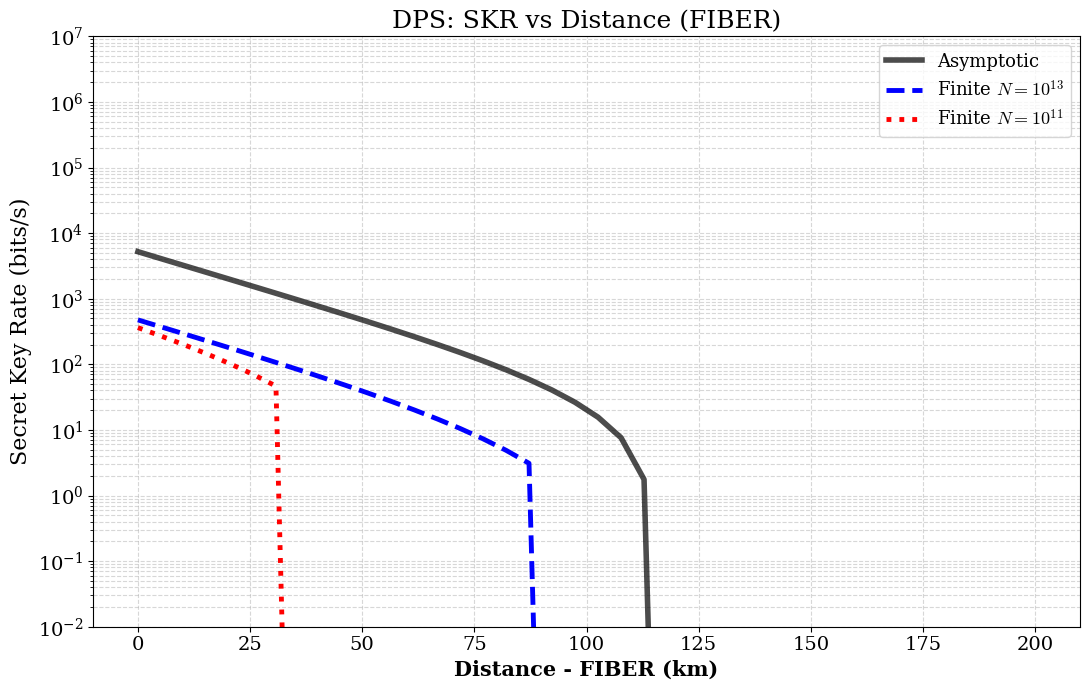


--- Processing FSO Channel ---


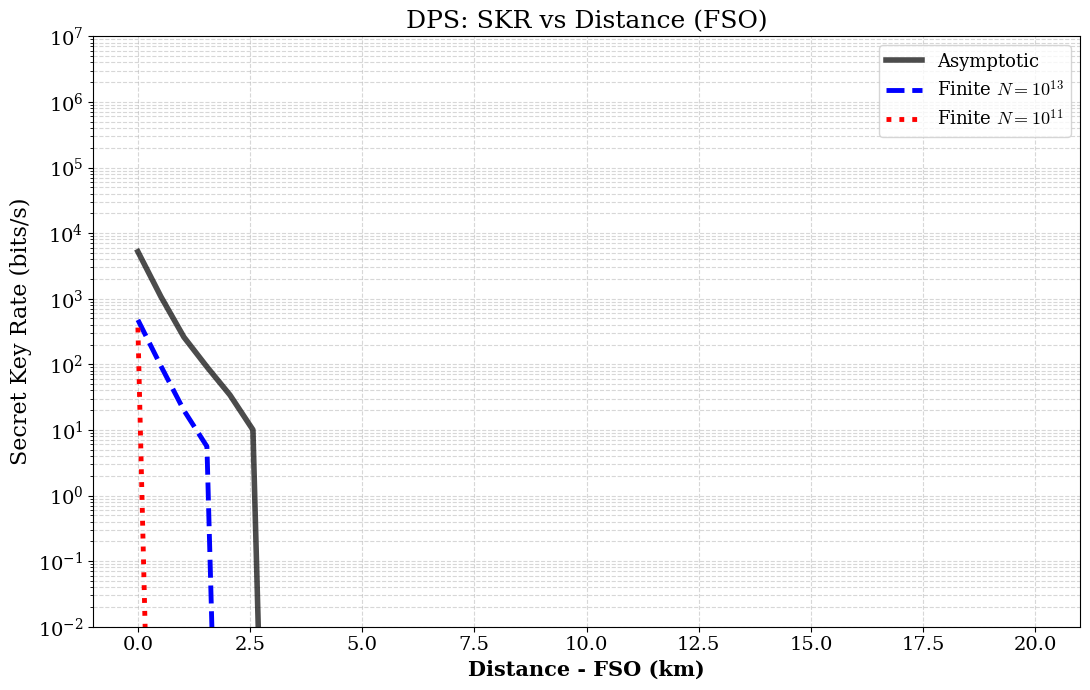

In [8]:
# Import DPS Simulators
from ThOPqkdsim.simDPS import DPSQKDSimulator as DPS_Asymptotic
from ThOPqkdsim.DPS_finite import DPSProtocol as DPS_Finite, IdealSinglePhotonSource, CoherentSource, Channel as FiniteChannel, Detector as FiniteDetector
from scipy.optimize import minimize_scalar, minimize
import numpy as np
import matplotlib.pyplot as plt

def get_optimized_fin_skr_2d(protocol):
    res = minimize(
        lambda x: -protocol.calculate_skr(x), 
        x0=[0.001, 0.8], 
        bounds=[(1e-4, 0.005), (0.5, 0.95)], 
        method='L-BFGS-B'
    )
    val = -res.fun
    return val if val > 1e-10 else 0.0

def get_optimized_fin_skr_t(protocol, mu_fixed):
    res = minimize_scalar(
        lambda t: -protocol.calculate_skr([mu_fixed, t]), 
        bounds=(0.1, 0.95), 
        method='bounded'
    )
    val = -res.fun
    return val if val > 1e-10 else 0.0

print("Generating Asymptotic vs Finite DPS Comparison graphs...")

modes = ['fiber', 'fso']

mu_values_fin = np.linspace(0.0001, 0.35, 40)
BLOCK_SIZES = [1e11, 1e13]
BLOCK_LABELS = ["10^{11}", "10^{13}"]

for mode in modes:
    print(f"\n--- Processing {mode.upper()} Channel ---")

    # Single shared distance array for both asymptotic and finite
    distances = np.linspace(0, 200, 40) if mode == 'fiber' else np.linspace(0, 20, 40)

    skr_asym_dist = []
    skr_fin_dist_N1 = []
    skr_fin_dist_N2 = []

    skr_asym_mu = []
    skr_fin_mu_N1 = []
    skr_fin_mu_N2 = []

    fixed_distance = 50.0 if mode == 'fiber' else 1.0
    fin_fixed_dist = 10.0 if mode == 'fiber' else 0.1

    fso_kwargs = {
        'transmitter_diameter': COMMON_PARAMS['transmitter_diameter'],
        'receiver_diameter': COMMON_PARAMS['receiver_diameter'],
        'beam_divergence': COMMON_PARAMS['beam_divergence'],
        'atmos_attenuation': COMMON_PARAMS['atmos_attenuation']
    } if mode == 'fso' else {}

    # Setup Asymptotic Protocol
    asym_dps = DPS_Asymptotic(
        repetition_rate=COMMON_PARAMS['repetition_rate'],
        mu=COMMON_PARAMS['mu'],
        eta_det=COMMON_PARAMS['eta_det'],
        dark_count=COMMON_PARAMS['dark_count_prob'],
        alpha=COMMON_PARAMS['alpha'],
        distance=fixed_distance,
        channel_mode=mode,
        errcorr_factor=COMMON_PARAMS['f_ec'],
        **fso_kwargs
    )

    # Setup Finite Protocol components
    source_fin = IdealSinglePhotonSource()
    channel_fin = FiniteChannel(
        mode=mode,
        distance_km=fixed_distance,
        alpha=COMMON_PARAMS['alpha'],
        transmitter_diameter=COMMON_PARAMS.get('transmitter_diameter', 0.1),
        receiver_diameter=COMMON_PARAMS.get('receiver_diameter', 0.3),
        beam_divergence=COMMON_PARAMS.get('beam_divergence', 10e-6),
        atmospheric_attenuation=COMMON_PARAMS.get('atmos_attenuation', 0.0)
    )
    detector_fin = FiniteDetector(
        dark_count_rate=COMMON_PARAMS['dark_count_hz'],
        efficiency=COMMON_PARAMS['eta_det'],
        time_window=COMMON_PARAMS['time_window']
    )

    # --- 1. Distance Variation (shared axis) ---
    for d in distances:
        asym_dps.update_distance(d)
        asym_dps.mu = COMMON_PARAMS['mu']
        skr_a = asym_dps.calculate_secret_key_rate()
        skr_asym_dist.append(max(1e-12, skr_a if skr_a is not None else 1e-12))

        channel_fin.set_distance(d)

        fin_prot_N1 = DPS_Finite(source_fin, channel_fin, detector_fin, n_em=BLOCK_SIZES[0],
                                  rep_rate=COMMON_PARAMS['repetition_rate'],
                                  epsilon_sec=COMMON_PARAMS['epsilon_sec'],
                                  f_ec=COMMON_PARAMS['f_ec'])
        skr_fin_dist_N1.append(max(1e-12, get_optimized_fin_skr_2d(fin_prot_N1)))

        fin_prot_N2 = DPS_Finite(source_fin, channel_fin, detector_fin, n_em=BLOCK_SIZES[1],
                                  rep_rate=COMMON_PARAMS['repetition_rate'],
                                  epsilon_sec=COMMON_PARAMS['epsilon_sec'],
                                  f_ec=COMMON_PARAMS['f_ec'])
        skr_fin_dist_N2.append(max(1e-12, get_optimized_fin_skr_2d(fin_prot_N2)))

    # --- 2. Mu Variation ---
    for mu_val in mu_values:
        asym_dps.update_distance(fixed_distance)
        asym_dps.mu = mu_val
        skr_a = asym_dps.calculate_secret_key_rate()
        skr_asym_mu.append(max(0, skr_a if skr_a is not None else 0))

    channel_fin.set_distance(fin_fixed_dist)
    for mu_fin in mu_values_fin:
        fin_prot_N1 = DPS_Finite(source_fin, channel_fin, detector_fin, n_em=BLOCK_SIZES[0],
                                  rep_rate=COMMON_PARAMS['repetition_rate'],
                                  epsilon_sec=COMMON_PARAMS['epsilon_sec'],
                                  f_ec=COMMON_PARAMS['f_ec'])
        skr_fin_mu_N1.append(max(0, get_optimized_fin_skr_t(fin_prot_N1, mu_fin)))

        fin_prot_N2 = DPS_Finite(source_fin, channel_fin, detector_fin, n_em=BLOCK_SIZES[1],
                                  rep_rate=COMMON_PARAMS['repetition_rate'],
                                  epsilon_sec=COMMON_PARAMS['epsilon_sec'],
                                  f_ec=COMMON_PARAMS['f_ec'])
        skr_fin_mu_N2.append(max(0, get_optimized_fin_skr_t(fin_prot_N2, mu_fin)))

    # --- Plot 1: SKR vs Distance (single axis) ---
    fig, ax = plt.subplots(figsize=(11, 7))

    ax.semilogy(distances, skr_asym_dist,  'k-',  linewidth=4, alpha=0.7, label='Asymptotic')
    ax.semilogy(distances, skr_fin_dist_N2, 'b--', linewidth=3.5, label=f'Finite $N={BLOCK_LABELS[1]}$')
    ax.semilogy(distances, skr_fin_dist_N1, 'r:',  linewidth=3.5, label=f'Finite $N={BLOCK_LABELS[0]}$')

    ax.set_xlabel(f'Distance - {mode.upper()} (km)', fontsize=15, weight='bold')
    ax.set_ylabel('Secret Key Rate (bits/s)', fontsize=16)
    ax.set_ylim(1e-2, 1e7)
    ax.tick_params(labelsize=14)
    ax.legend(fontsize=13, loc='upper right')
    ax.grid(True, which='both', ls='--', alpha=0.5)
    plt.title(f'DPS: SKR vs Distance ({mode.upper()})', fontsize=18)
    plt.tight_layout()
    plt.show()

    # --- Plot 2: SKR vs Mu (single axis) ---
    # fig, ax = plt.subplots(figsize=(11, 7))

    # ax.plot(mu_values,     skr_asym_mu,   'k-',  linewidth=4, alpha=0.7, label='Asymptotic')
    # ax.plot(mu_values_fin, skr_fin_mu_N2, 'b--', linewidth=3.5, label=f'Finite $N={BLOCK_LABELS[1]}$')
    # ax.plot(mu_values_fin, skr_fin_mu_N1, 'r:',  linewidth=3.5, label=f'Finite $N={BLOCK_LABELS[0]}$')

    # ax.set_xlabel(r'Mean Photon Number ($\mu$)', fontsize=15, weight='bold')
    # ax.set_ylabel('Secret Key Rate (bits/s)', fontsize=16)
    # ax.tick_params(labelsize=14)
    # ax.legend(fontsize=13, loc='upper right')
    # ax.grid(True, which='both', ls='--', alpha=0.5)
    # plt.title(f'DPS: SKR vs $\mu$ ({mode.upper()})', fontsize=18)
    # plt.tight_layout()
    # plt.show()